##### NOTEBOOK 1 ==> EDA ON THE MSRC V2 Image Dataset 

##### Objectives:
##### - Verify dataset structure and integrity
##### - Explore class distribution
##### - Examine image size and colour statistics
##### - Visualize sample images for intuition

In [14]:
# Importing Libs
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from datetime import datetime
import plotly.express as px
import pandas as pd
from pathlib import Path
# Pretty plots
sns.set(style="whitegrid")

DATA_DIR = Path("/home/sally/Desktop/Desktop/coursework/computervision/visual-image-search/data/data/MSRC_ObjCategImageDatabase_v2/Images")
## Using assert to write a test case for it the path exist
assert DATA_DIR.exists(), "Dataset not found! Make sure you've downloaded and extracted MSRC-v2."


In [ ]:
### Load Image Paths and Basic Overview

def get_all_images(root: Path):
    return [p for p in root.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]

paths = get_all_images(DATA_DIR)
print(f"** Total images found: {len(paths)}")

# Infer class names from folder structure
classes = [p.parent.name for p in paths]
unique_classes = sorted(set(classes))
print(f" ** Classes detected ({len(unique_classes)}): {unique_classes}")



✅ Total images found: 591
✅ Classes detected (1): ['Images']


/tmp/ipykernel_8384/1412481991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis",legend=False)


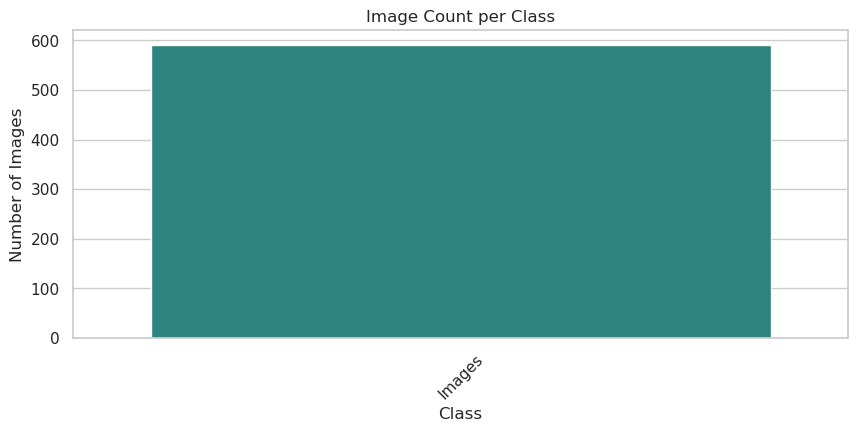

In [3]:
### Class Distribution (Bar Chart)

counts = {c: classes.count(c) for c in unique_classes}
plt.figure(figsize=(10, 4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis",legend=False)
plt.xticks(rotation=45)
plt.title("Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


Computing sizes (sample): 100%|██████████| 500/500 [00:00<00:00, 1415.75it/s]


Average Width × Height: 307.3 × 231.2


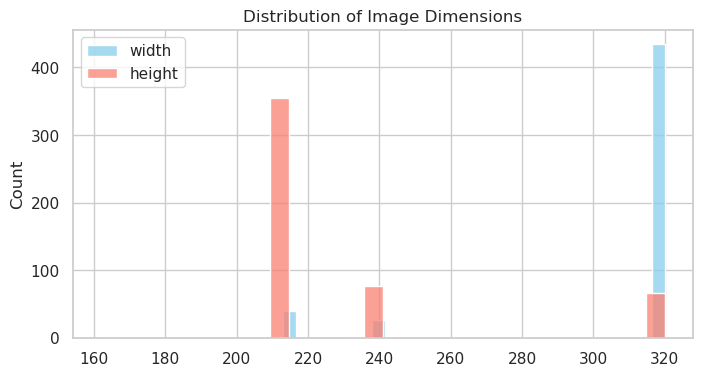

In [4]:
### Image Size Distribution

widths, heights = [], []
for p in tqdm(paths[:500], desc="Computing sizes (sample)"):
    img = cv2.imread(str(p))
    if img is None: continue
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)

print(f"Average Width × Height: {np.mean(widths):.1f} × {np.mean(heights):.1f}")
plt.figure(figsize=(8, 4))
sns.histplot(widths, bins=30, color="skyblue", label="width")
sns.histplot(heights, bins=30, color="salmon", label="height")
plt.legend()
plt.title("Distribution of Image Dimensions")
plt.show()


Sampling for colour stats: 100%|██████████| 200/200 [00:00<00:00, 235.74it/s]


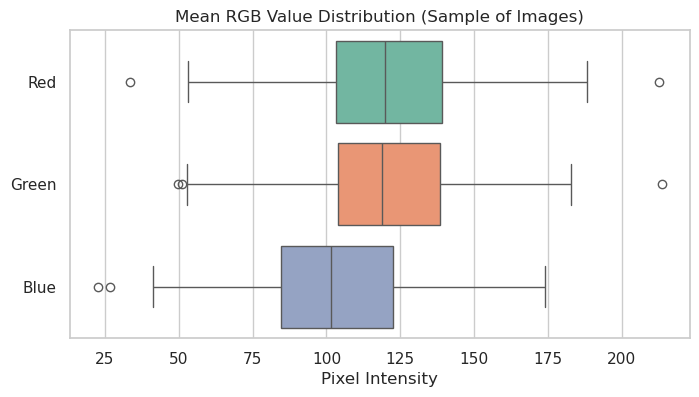

In [5]:
### Colour Statistics (Mean RGB values across random sample data)

means, stds = [], []
sample_paths = np.random.choice(paths, size=min(200, len(paths)), replace=False)
for p in tqdm(sample_paths, desc="Sampling for colour stats"):
    img = cv2.imread(str(p))
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.array(means)
plt.figure(figsize=(8, 4))
sns.boxplot(data=means, orient="h", palette="Set2")
plt.xlabel("Pixel Intensity")
plt.yticks([0, 1, 2], ["Red", "Green", "Blue"])
plt.title("Mean RGB Value Distribution (Sample of Images)")
plt.show()


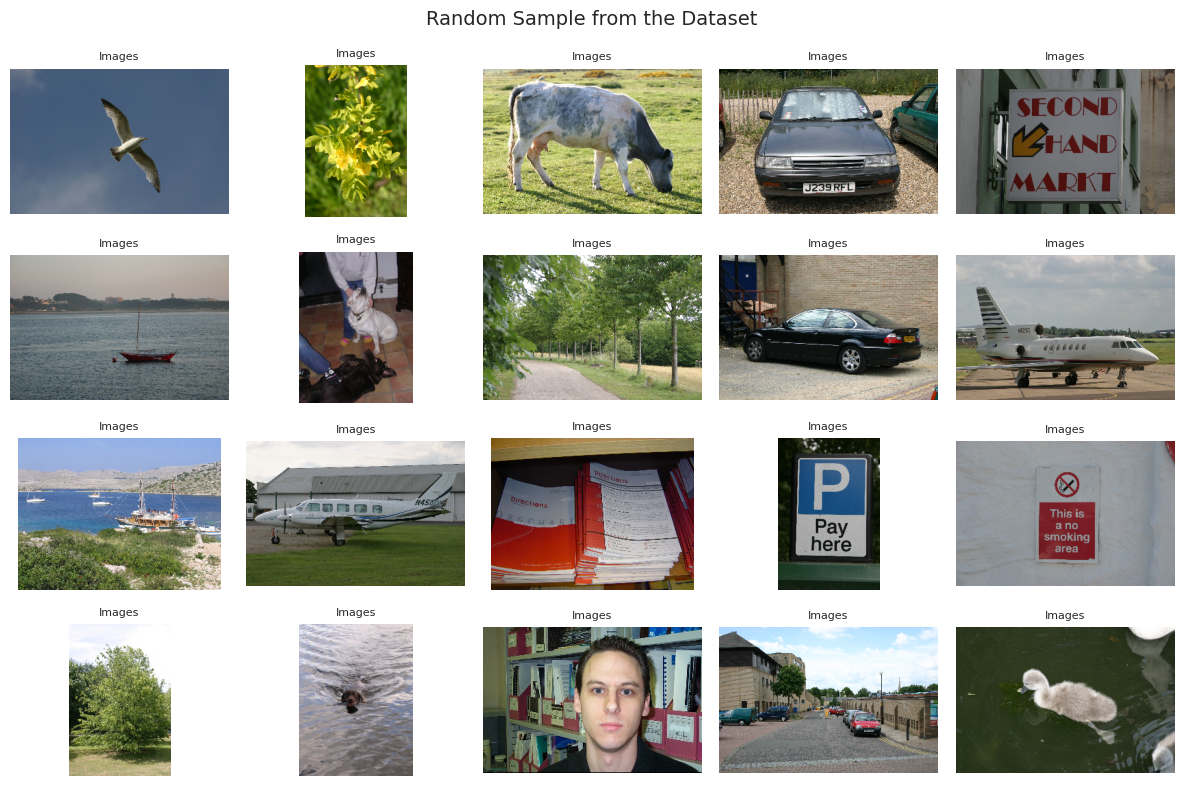

In [ ]:
### Random Image Grid (Visual Inspection) for the Image Dataset 

import random

plt.figure(figsize=(12, 8))
for i, p in enumerate(random.sample(paths, 20)):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.parent.name, fontsize=8)
plt.suptitle("Random Sample from the Dataset", fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
###  Average Image per Class

def average_image_per_class(root: Path, class_name: str, n_max=50):
    imgs = list((root / class_name).rglob("*.[jp][pn]g"))
    imgs = imgs[:n_max]
    acc = []
    for p in imgs:
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.resize(img, (64, 64))
        acc.append(img.astype(np.float32))
    if not acc: return None
    avg = np.mean(acc, axis=0).astype(np.uint8)
    return cv2.cvtColor(avg, cv2.COLOR_BGR2RGB)


cols = 5
plt.figure(figsize=(12, 6))
for i, cls in enumerate(unique_classes[:cols * 2]):
    avg_img = average_image_per_class(DATA_DIR, cls)
    if avg_img is None: continue
    plt.subplot(2, cols, i + 1)
    plt.imshow(avg_img)
    plt.axis("off")
    plt.title(cls)
plt.suptitle("Average Colour per Class (approx.)", fontsize=14)
plt.show()


<Figure size 1200x600 with 0 Axes>

In [ ]:
### Exporting EDA Figures and Summary Table
#


FIG_DIR = Path("../report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


# -- Save Figures -------------------------------------------------------------
def save_current_figure(name: str):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"** Saved figure: {path.name}")




# Previous Plots
plt.figure(figsize=(10, 4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.xticks(rotation=45)
plt.title("Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
save_current_figure("class_distribution")
plt.close()

plt.figure(figsize=(8, 4))
sns.histplot(widths, bins=30, color="skyblue", label="width")
sns.histplot(heights, bins=30, color="salmon", label="height")
plt.legend()
plt.title("Image Dimension Distribution")
save_current_figure("image_dimensions")
plt.close()

plt.figure(figsize=(8, 4))
sns.boxplot(data=means, orient="h", palette="Set2")
plt.xlabel("Pixel Intensity")
plt.yticks([0, 1, 2], ["Red", "Green", "Blue"])
plt.title("Mean RGB Value Distribution (Sample of Images)")
save_current_figure("rgb_distribution")
plt.close()

###  Summary Table Creation

summary = []
for cls in unique_classes:
    cls_paths = [p for p in paths if p.parent.name == cls]
    # compute average image size for this class
    sizes = []
    for p in cls_paths[:50]:
        img = cv2.imread(str(p))
        if img is None: continue
        h, w = img.shape[:2]
        sizes.append((w, h))
    if not sizes: continue
    avg_w, avg_h = np.mean(sizes, axis=0)
    summary.append({
        "Class": cls,
        "Num_Images": len(cls_paths),
        "Avg_Width": round(avg_w, 1),
        "Avg_Height": round(avg_h, 1)
    })

df_summary = pd.DataFrame(summary).sort_values("Num_Images", ascending=False)
df_summary.reset_index(drop=True, inplace=True)
df_summary.head()

# Save to CSV for report tables
csv_path = Path("../report/dataset_summary.csv")
df_summary.to_csv(csv_path, index=False)
print(f"** Saved dataset summary to {csv_path}")

# Timestamp metadata
with open(FIG_DIR / "eda_log.txt", "w") as f:
    f.write(f"EDA run completed: {datetime.now()}\n")
    f.write(f"Total images: {len(paths)}\nClasses: {len(unique_classes)}\n")
    f.write("Exported figures:\n")
    for name in ["class_distribution", "image_dimensions", "rgb_distribution"]:
        f.write(f" - {name}.png\n")
print("** EDA figures and log saved successfully.")


/tmp/ipykernel_8384/2103692621.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


✅ Saved figure: class_distribution.png
✅ Saved figure: image_dimensions.png
✅ Saved figure: rgb_distribution.png
✅ Saved dataset summary to ../report/dataset_summary.csv
✅ EDA figures and log saved successfully.


Extracting mean RGB features: 100%|██████████| 300/300 [00:00<00:00, 4068.94it/s]

Feature matrix shape: (300, 12288)


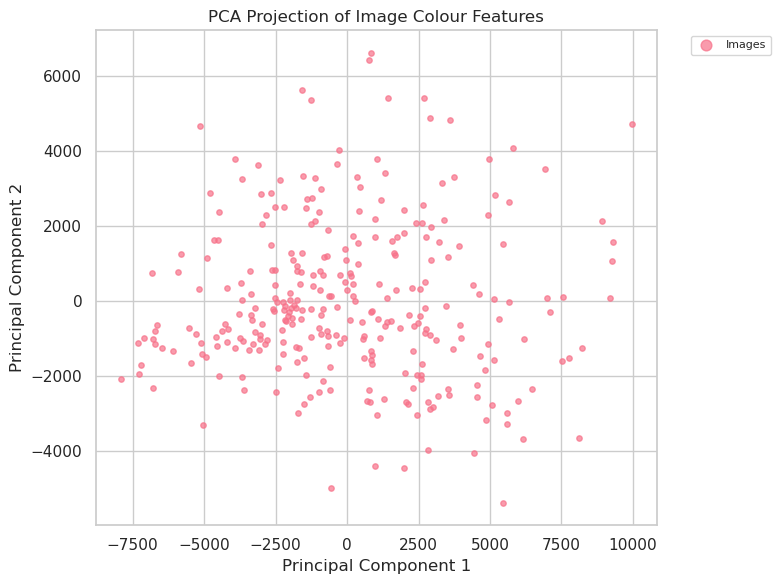

In [9]:
## PCA Visualization of Image Appearance
#
# Reduce sampled images into 2D using PCA on colour features.
# Each point = one image; colour indicates its class.


from sklearn.decomposition import PCA
import random

sample_size = min(300, len(paths))
sample_paths = random.sample(paths, sample_size)

features, labels = [], []
for p in tqdm(sample_paths, desc="Extracting mean RGB features"):
    img = cv2.imread(str(p))
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_small = cv2.resize(img, (64, 64))  # reduce dimensionality
    features.append(img_small.flatten())  # vectorize
    labels.append(p.parent.name)

features = np.array(features)
print(f"Feature matrix shape: {features.shape}")

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(features)

plt.figure(figsize=(8, 6))
unique_labels = sorted(set(labels))
palette = sns.color_palette("husl", len(unique_labels))
label_to_color = {lbl: palette[i] for i, lbl in enumerate(unique_labels)}

for lbl in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=15, color=label_to_color[lbl], label=lbl, alpha=0.7)

plt.title("PCA Projection of Image Colour Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Extracting mean RGB features: 100%|██████████| 300/300 [00:00<00:00, 4284.23it/s]


Feature matrix shape: (300, 12288)


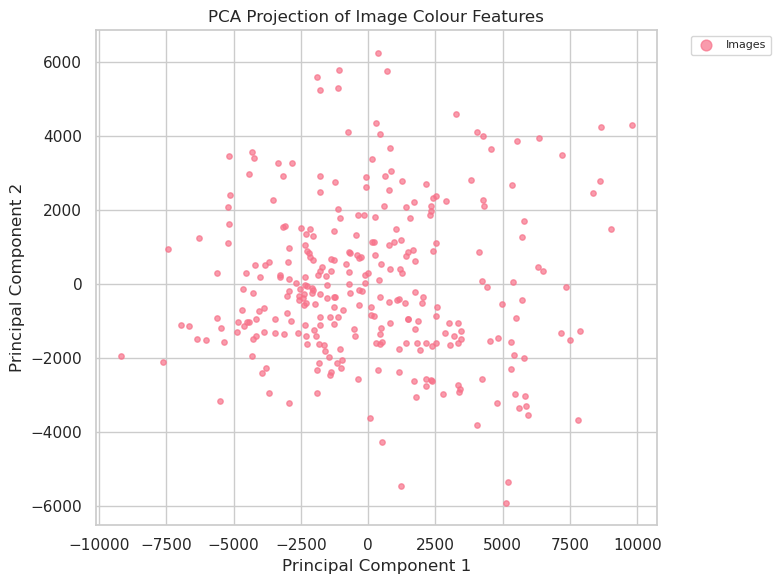

✅ Saved PCA coordinates to ../report/pca_distribution.csv


,PC1,PC2,PC3,Label
0,-5629.281772,307.920776,-10.088913,Images
1,645.220430,2933.835086,-2030.740975,Images
2,2771.126518,-2965.744350,-662.592326,Images
3,-376.248263,-2580.968685,-3962.201243,Images
4,1673.299818,930.474240,194.862884,Images


In [ ]:
### PCA Visualization of Image Appearance
#
# Reduce sampled images into 2D using PCA on colour features.
# Each point = one image; colour indicates its class.
#
#
# - Tight, distinct clusters → colour/texture differences dominate.
# - Overlapping clusters → likely need shape or texture descriptors.

from sklearn.decomposition import PCA
import random
import pandas as pd

sample_size = min(300, len(paths))
sample_paths = random.sample(paths, sample_size)

features, labels = [], []
for p in tqdm(sample_paths, desc="Extracting mean RGB features"):
    img = cv2.imread(str(p))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_small = cv2.resize(img, (64, 64))  # reduce dimensionality
    features.append(img_small.flatten())  # vectorize
    labels.append(p.parent.name)

features = np.array(features)
print(f"Feature matrix shape: {features.shape}")

# --- PCA fitting ---
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(features)

# --- Visualization ---
plt.figure(figsize=(8, 6))
unique_labels = sorted(set(labels))
palette = sns.color_palette("husl", len(unique_labels))
label_to_color = {lbl: palette[i] for i, lbl in enumerate(unique_labels)}

for lbl in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=15, color=label_to_color[lbl],
                label=lbl, alpha=0.7)

plt.title("PCA Projection of Image Colour Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1),
           loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Saving PCA Coordinates to CSV
from pathlib import Path

# Create DataFrame with PCA components and labels
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "Label": labels
})

# Saving PCA file
pca_csv_path = Path("../report/pca_distribution.csv")
df_pca.to_csv(pca_csv_path, index=False)
print(f"** Saved PCA coordinates to {pca_csv_path}")
df_pca.head()


In [16]:
### Interactive 3D PCA Scatter (Plotly)
#
# Exploring clusters by rotating, zooming, and hovering.
# Each point = one image; colour = class label.


# Reloading saved PCA data for viz
pca_csv_path = Path("../report/pca_distribution.csv")
df_pca = pd.read_csv(pca_csv_path)

# using the values of the pcs csv to make the values
fig = px.scatter_3d(
    df_pca,
    x="PC1", y="PC2", z="PC3",
    color="Label",
    hover_name="Label",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Safe,
    title="Interactive 3D PCA Visualization of Image Colour Features"
)

fig.update_traces(marker=dict(size=4, line=dict(width=0)))
fig.update_layout(
    legend_title_text="Class",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3",
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
